# Reducing Overfitting

Original Feature - Train MSE: 280.367, Test MSE: 446.553
Discretized Feature - Train MSE: 339.937, Test MSE: 475.515


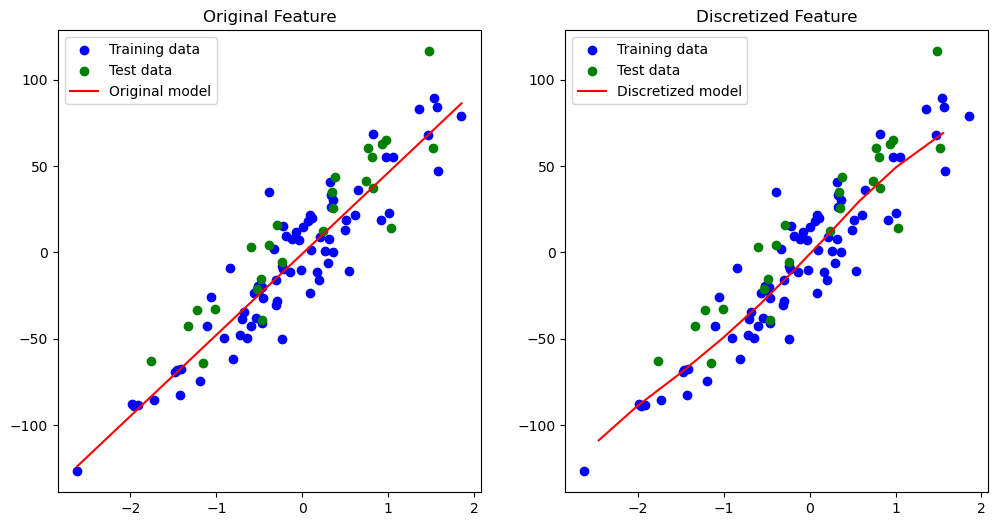

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer

# Generate synthetic data
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Linear regression with the original feature
model_original = LinearRegression()
model_original.fit(X_train, y_train)
y_train_pred_orig = model_original.predict(X_train)
y_test_pred_orig = model_original.predict(X_test)

# Discretize the feature
disc = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans')
X_train_disc = disc.fit_transform(X_train)
X_test_disc = disc.transform(X_test)

# Linear regression with the discretized feature
model_disc = LinearRegression()
model_disc.fit(X_train_disc, y_train)
y_train_pred_disc = model_disc.predict(X_train_disc)
y_test_pred_disc = model_disc.predict(X_test_disc)

# Calculate and print MSE for both models
mse_train_orig = mean_squared_error(y_train, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test, y_test_pred_orig)
mse_train_disc = mean_squared_error(y_train, y_train_pred_disc)
mse_test_disc = mean_squared_error(y_test, y_test_pred_disc)

print(f'Original Feature - Train MSE: {mse_train_orig:.3f}, Test MSE: {mse_test_orig:.3f}')
print(f'Discretized Feature - Train MSE: {mse_train_disc:.3f}, Test MSE: {mse_test_disc:.3f}')

# Plotting to visualize overfitting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(np.sort(X_train, axis=0), model_original.predict(np.sort(X_train, axis=0)), color='red', label='Original model')
plt.title('Original Feature')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
# For discretized model, predictions are plotted against the mid-point of each bin
bin_edges = disc.bin_edges_[0]
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_mids, model_disc.predict(disc.transform(bin_mids.reshape(-1, 1))), color='red', label='Discretized model')
plt.title('Discretized Feature')
plt.legend()

plt.show()
